# MES SuperTrend flip, long-only, 15-minute bars (Tradovate exchange)

Same event-driven engine, cost model, and strategy
(`backtester.strategies.SuperTrendFlipStrategy`) as the original
`supertrend_flip_mes.ipynb`, which tested `direction=both` on 5-minute bars and
found every combo net-negative (best `dollar_profit_factor` 1.01, 4 of 6
combos breaching the drawdown middleware even with a hard stop-loss).

**Why retry it**: the Donchian breakout research in this pipeline found that
switching from `direction=both` to `direction=long` and from 5-minute to
15-minute bars turned a consistently negative result into this repo's
best-supported strategy candidate (walk-forward `trade_sharpe_lb` positive on
both MES and, more strongly, MNQ). SuperTrend is a structurally different
signal (ATR-ratcheting trailing stop/trend flip vs. a static N-bar channel),
but if the earlier failure was partly about direction (stop-and-reverse forces
taking every short signal too, and shorts fought MES's bull drift the same way
Donchian's did) and partly about noise at 5-minute resolution, the same two
fixes are worth testing here before concluding SuperTrend has no edge on MES.

**Mechanical difference from Donchian worth noting up front**: with
`direction=long`, `SuperTrendFlipStrategy` is no longer a true stop-and-reverse
system -- on a down-flip it exits to flat and *waits* for the next up-flip,
rather than immediately opening a short. Exit is still the indicator's own
flip logic (or the hard stop-loss frozen at entry, whichever comes first) --
see that strategy's docstring for the full risk-management rationale (an
earlier build with no hard stop blew through this repo's drawdown middleware
on real data).


In [1]:
import os
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import HTML, display

from backtester.backtest_runner import Backtester
from backtester.exchange import Exchange, MarginAllocationType, MarketType, TradovateSymbolConfigProvider
from backtester.exchange.event_log import OrderFilled
from backtester.exchange_config import TRADOVATE_FUTURES
from backtester.indicators import Indicators
from backtester.market import Market
from backtester.middleware import MaxDailyLossMiddleware, TradeifyDrawdownMiddleware
from backtester.performance import PerformanceAnalyzer
from backtester.portfolio import Portfolio, WeightedStrategy
from backtester.strategies import StrategyDirection, SuperTrendFlipStrategy
from data_aggregator.databento_aggregator import load_1m_parquet_resampled

cwd = os.getcwd()
print(cwd)


/Users/nick/Documents/www/alphakit/notebooks/pipelines/breakout


In [2]:
def _find_upwards(relative_path: str, start: Path) -> Path:
    for ancestor in [start, *start.parents]:
        candidate = ancestor / relative_path
        if candidate.exists():
            return candidate
    raise FileNotFoundError(
        f"Could not find {relative_path} above {start} -- run "
        "data_aggregator.databento_aggregator to download it first."
    )


DISPLAY_SYMBOL = "MES"
SYMBOL = "MES/USD"
INTERVAL = 15
UNIT_OF_TIME = "minute"

mes_path = _find_upwards("apps/backtester/datasets/databento/MES_c_0_1m.parquet", start=Path(cwd))
ohlc = load_1m_parquet_resampled(mes_path, interval=INTERVAL, unit_of_time=UNIT_OF_TIME)
print(f"Bars: {len(ohlc)}  span: {ohlc.index[0]} -> {ohlc.index[-1]}")


Bars: 168278  span: 2019-05-05 22:14:59.999000 -> 2026-07-12 23:14:59.999000


## Grid search: SuperTrend length x ATR multiplier, direction=long

`risk_reward_ratio=None` (canonical: no fixed take-profit, exit on the next
flip or the hard stop, whichever comes first) -- same convention as the
original notebook's Pass 1.


In [3]:
LENGTH_CANDIDATES = [7, 10, 20, 30, 50]
MULTIPLIER_CANDIDATES = [2.0, 3.0, 4.0]
DEPOSIT_USD = 50_000


def run_supertrend_backtest(ohlc_slice: pd.DataFrame, length: int, multiplier: float, key: str,
                             direction: StrategyDirection = StrategyDirection.long,
                             risk_reward_ratio: float | None = None):
    line, direction_series = Indicators.supertrend(ohlc_slice, length=length, multiplier=multiplier)

    market = Market()
    market.add_market(symbol=SYMBOL, df=ohlc_slice)
    market.add_indicator(symbol=SYMBOL, interval=INTERVAL, unit_of_time=UNIT_OF_TIME, indicator_name="line", df=line)
    market.add_indicator(symbol=SYMBOL, interval=INTERVAL, unit_of_time=UNIT_OF_TIME,
                          indicator_name="direction", df=direction_series)
    market.compile()

    portfolio = Portfolio(weighted_strategies=[
        WeightedStrategy(weight=1.0, strategy=SuperTrendFlipStrategy(
            key=key, market=market, symbol=SYMBOL, line_key="line", direction_key="direction",
            risk_reward_ratio=risk_reward_ratio, direction=direction,
        )),
    ], output_scale=1)

    symbol_config_provider = TradovateSymbolConfigProvider(symbols=TRADOVATE_FUTURES, default_fee_per_contract=0.0)
    exchange = Exchange(
        market=market, slippage=0.0, maker_fee=0.0, taker_fee=0.0,
        market_type=MarketType.future, max_leverage=10,
        margin_allocation_type=MarginAllocationType.cross,
        symbol_config_provider=symbol_config_provider,
    )
    reporter = PerformanceAnalyzer(market=market, exchange=exchange, portfolio=portfolio,
                                    benchmark_symbols=[SYMBOL], periods_per_year=252)

    market.reset()
    drawdown_middleware = TradeifyDrawdownMiddleware(drawdown_percent=0.5)
    daily_loss_middleware = MaxDailyLossMiddleware(max_loss_percent=0.5)
    backtest = Backtester(market=market, portfolio=portfolio, exchange=exchange, reporter=reporter,
                           middlewares=[daily_loss_middleware, drawdown_middleware])
    backtest.exchange.transactions.add_deposit(asset="USD", volume=DEPOSIT_USD)
    backtest.run_all()
    return backtest, drawdown_middleware


grid_rows = []
grid_backtests = {}
_t0 = time.time()
for length in LENGTH_CANDIDATES:
    for multiplier in MULTIPLIER_CANDIDATES:
        bt, drawdown_mw = run_supertrend_backtest(ohlc, length, multiplier, key=f"ST_long_{length}_{multiplier}")
        summary = bt.reporter.summary["algo"]
        total_fees = sum(e.fees_volume for e in bt.exchange.event_log.get_events() if isinstance(e, OrderFilled))
        grid_backtests[(length, multiplier)] = (bt, drawdown_mw)
        grid_rows.append({
            "length": length, "multiplier": multiplier,
            "net_return_percent": summary["net_return_percent"], "sharpe_ratio": summary["sharpe_ratio"],
            "max_drawdown_percent": summary["max_drawdown_percent"], "closed_trades": summary["closed_trades"],
            "trades_per_year": round(summary["closed_trades"] / 7.2, 1), "win_rate_percent": summary["win_rate_percent"],
            "profit_factor": summary["profit_factor"], "r_multiple_expectancy": summary["r_multiple_expectancy"],
            "dollar_profit_factor": summary["dollar_profit_factor"], "dollar_expectancy": summary["dollar_expectancy"],
            "total_fees_usd": total_fees, "account_failed": drawdown_mw.account_failed,
        })
    print(f"length={length} done, {time.time() - _t0:.0f}s elapsed", flush=True)

grid_results = pd.DataFrame(grid_rows).sort_values("sharpe_ratio", ascending=False).reset_index(drop=True)
print(f"\ngrid done in {time.time() - _t0:.0f}s\n")
print(grid_results.to_string())


length=7 done, 58s elapsed


length=10 done, 123s elapsed


length=20 done, 204s elapsed


length=30 done, 274s elapsed


length=50 done, 344s elapsed



grid done in 344s

    length  multiplier  net_return_percent  sharpe_ratio  max_drawdown_percent  closed_trades  trades_per_year  win_rate_percent  profit_factor  r_multiple_expectancy  dollar_profit_factor  dollar_expectancy  total_fees_usd  account_failed
0       50         3.0           34.389252      0.343418              -24.3801         2161.0            300.1         38.593244       1.184457               0.087672              1.117779          11.604371         7882.42           False
1       20         4.0           28.224845      0.308345              -27.9332         1395.0            193.8         40.000000       1.170299               0.089114              1.112942          13.850367         5208.84           False
2       30         4.0           28.359383      0.299254              -30.5291         1405.0            195.1         40.427046       1.164213               0.086824              1.114093          13.680492         5041.40           False
3       50         4

### Heatmaps: Sharpe ratio and net return across (length, multiplier)


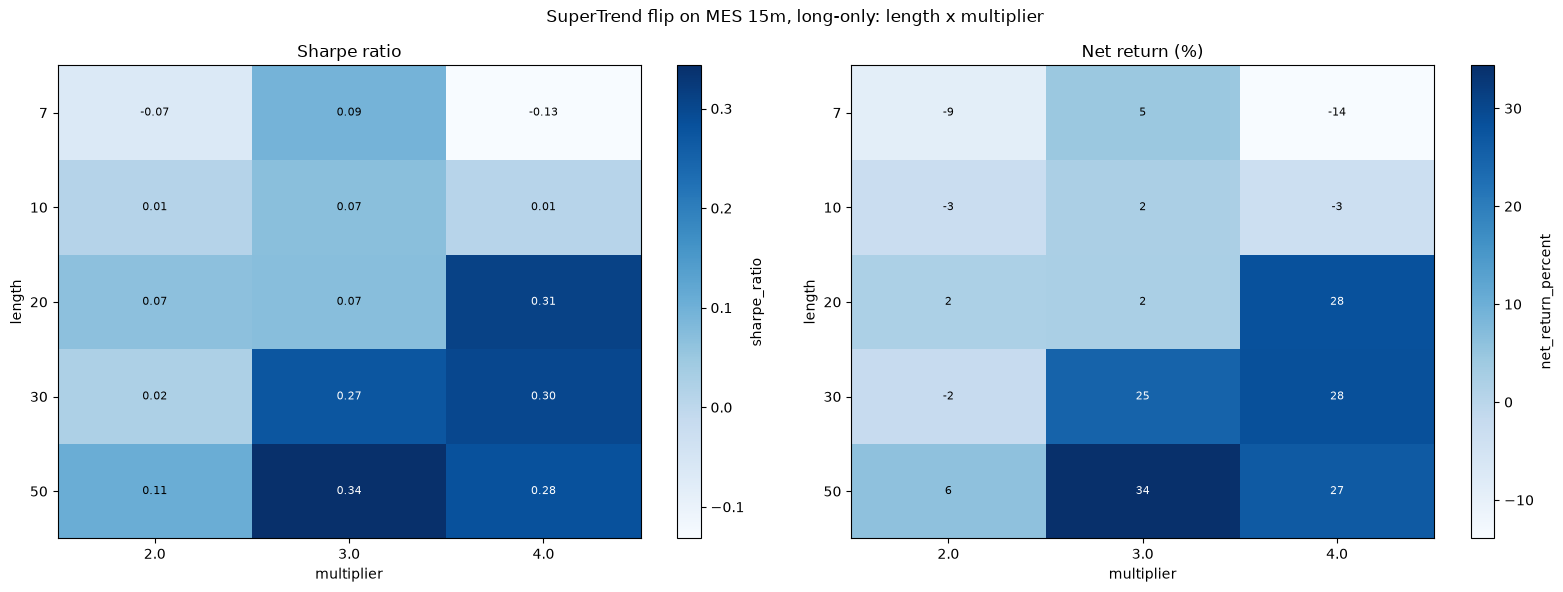

In [4]:
def _plot_heatmap(ax, pivot: pd.DataFrame, title: str, fmt: str):
    values = pivot.values.astype(float)
    vmin, vmax = np.nanmin(values), np.nanmax(values)
    span = vmax - vmin if vmax > vmin else 1.0
    im = ax.imshow(values, cmap="Blues", aspect="auto")
    ax.set_xticks(range(len(pivot.columns)), labels=[str(c) for c in pivot.columns])
    ax.set_yticks(range(len(pivot.index)), labels=[str(i) for i in pivot.index])
    ax.set_xlabel("multiplier")
    ax.set_ylabel("length")
    ax.set_title(title)
    for i in range(values.shape[0]):
        for j in range(values.shape[1]):
            val = values[i, j]
            normalized = (val - vmin) / span
            ax.text(j, i, format(val, fmt), ha="center", va="center", fontsize=8,
                    color="white" if normalized > 0.6 else "black")
    return im


sharpe_pivot = grid_results.pivot(index="length", columns="multiplier", values="sharpe_ratio")
return_pivot = grid_results.pivot(index="length", columns="multiplier", values="net_return_percent")

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
im0 = _plot_heatmap(axes[0], sharpe_pivot, "Sharpe ratio", ".2f")
fig.colorbar(im0, ax=axes[0], label="sharpe_ratio")
im1 = _plot_heatmap(axes[1], return_pivot, "Net return (%)", ".0f")
fig.colorbar(im1, ax=axes[1], label="net_return_percent")
fig.suptitle("SuperTrend flip on MES 15m, long-only: length x multiplier")
fig.tight_layout()
plt.show()


## Detailed report for the best combo

Full HTML summary (year-by-year split) and equity/drawdown charts for the
grid's best combo -- same report format as every other notebook in this
pipeline.


Best combo: length=50, multiplier=3.0
Candles Processed: 168277
Account failed (drawdown breach): False


metric,algo,algo_2019,algo_2020,algo_2021,algo_2022,algo_2023,algo_2024,algo_2025,algo_2026,MES/USD,description
sharpe_ratio,0.3434,0.0883,0.0977,1.1292,-0.1749,0.6123,1.5075,0.0794,0.6134,0.6392,"Return per unit of total volatility. <0 bad, ~1 decent, >2 great, >3 excellent."
sortino_ratio,0.5043,0.1424,0.1343,1.7168,-0.2812,0.9869,2.7845,0.1101,1.0346,0.9137,"Like Sharpe but only penalizes downside volatility (upside swings aren't ""risk""). >2 good, >3 excellent."
annualized_volatility_percent,9.6099,6.6120,16.3093,6.7398,10.9129,5.8031,6.7093,10.7340,4.6355,16.6830,How much the equity curve swings per year. Lower = smoother.
cagr_percent,4.1955,0.5326,0.3774,11.3184,-3.5666,5.0398,15.4449,0.4002,4.0647,14.3689,"Compound annual growth rate, the smoothed annual growth rate. Higher is generally better, but always weigh against volatility/drawdown."
calmar_ratio,0.1721,0.0935,0.0156,1.6657,-0.3549,0.6569,3.8654,0.0271,0.9645,0.4057,"CAGR ÷ max drawdown. >1 decent, >3 excellent, <0.5 weak."
recovery_factor,1.4105,0.0614,0.0156,1.6608,-0.3539,0.6550,3.8654,0.0270,0.5026,4.5918,Total net profit ÷ max drawdown. >2 solid.
max_drawdown_percent,-24.3801,-5.6946,-24.1541,-6.7951,-10.0499,-7.6726,-3.9957,-14.7753,-4.2143,-35.4168,Largest peak-to-trough loss. Closer to 0 better; below -20% starts getting painful for most investors.
max_drawdown_duration_days,711,111,319,149,271,166,55,321,64,719,How long it took to recover the loss. Shorter is better.
ulcer_index,5.6257,2.9941,11.4712,1.8667,5.0439,2.9047,1.0486,5.3332,1.3290,8.4634,"Combines depth and duration of drawdowns into one number. Lower is better (less ""ulcer-inducing"")."
var_95_percent,-0.7211,-0.5664,-1.4228,-0.5141,-0.9611,-0.5354,-0.5140,-0.7368,-0.4100,-1.4858,"The daily loss you shouldn't exceed on a ""normal"" bad day (worst of the best 95%). Closer to 0 is better."


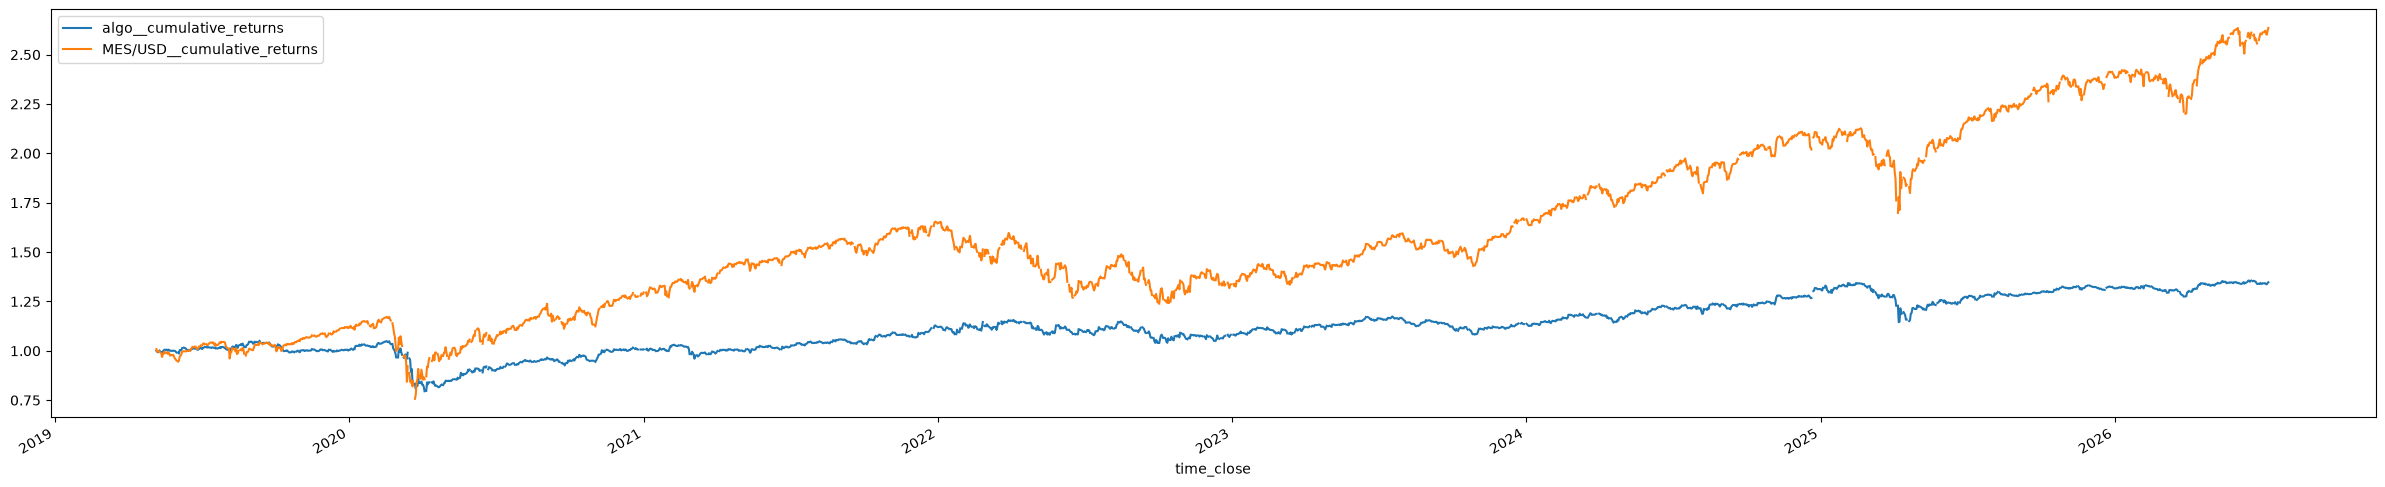

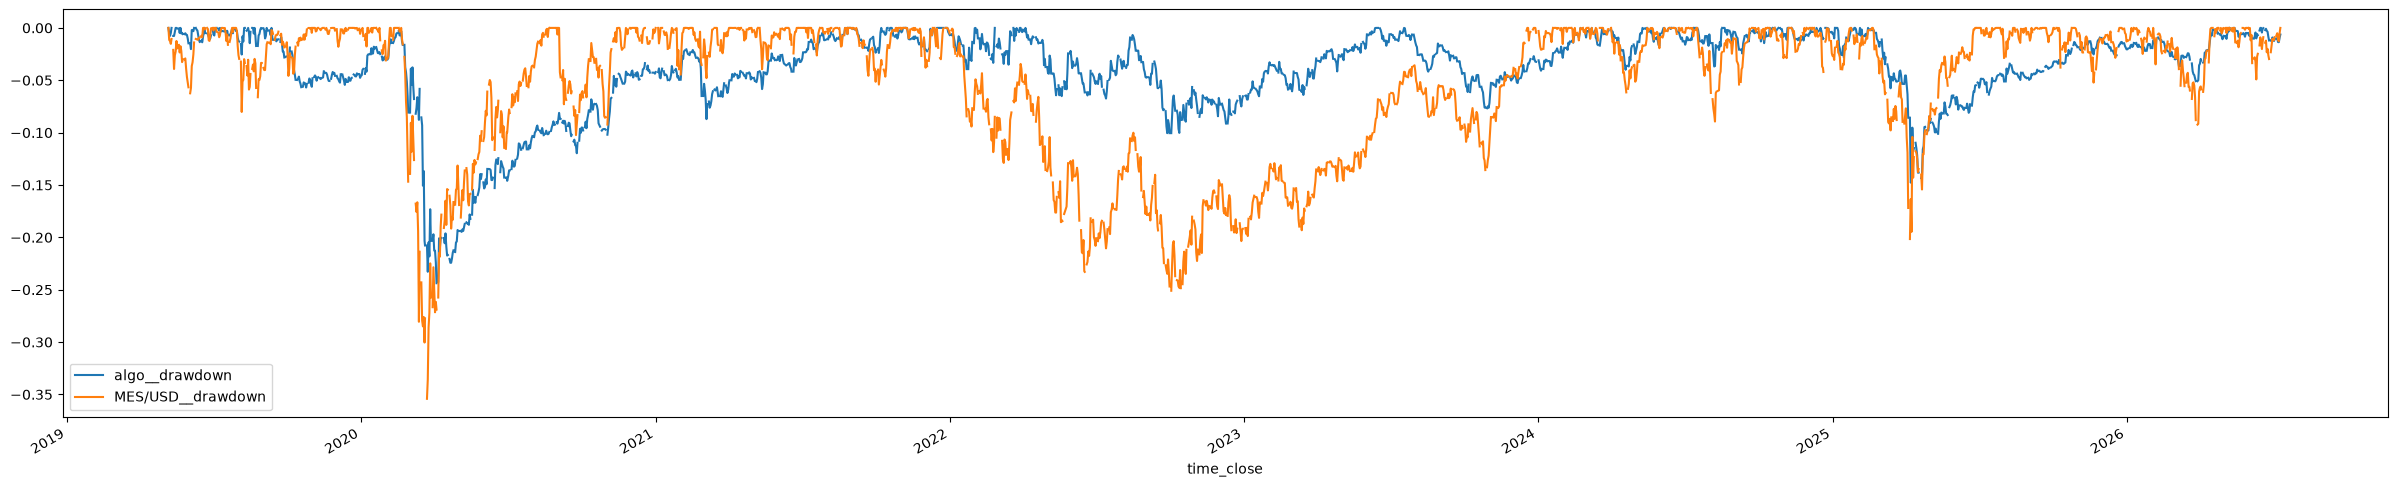

In [5]:
best_length, best_mult = grid_results.iloc[0][["length", "multiplier"]]
best_length = int(best_length)
print(f"Best combo: length={best_length}, multiplier={best_mult}")
best_backtest, best_drawdown_mw = grid_backtests[(best_length, best_mult)]

print("Candles Processed:", best_backtest.market.current["num"])
print("Account failed (drawdown breach):", best_drawdown_mw.account_failed)

display(HTML(best_backtest.reporter.summary_html_table(split="Y")))

if best_backtest.reporter.merged is not None:
    best_backtest.reporter.merged.plot(x="time_close", y=[
        "algo__cumulative_returns",
        f"{SYMBOL}__cumulative_returns",
    ], figsize=(30, 6))

    best_backtest.reporter.merged.plot(x="time_close", y=[
        "algo__drawdown",
        f"{SYMBOL}__drawdown",
    ], figsize=(30, 6))


## Holdout check: does the best combo survive a train/test split?


In [6]:
split_idx = int(len(ohlc) * 0.75)
split_date = ohlc.index[split_idx]
print(f"train/test split at {split_date}  ({split_idx} train bars, {len(ohlc) - split_idx} test bars)")

train_ohlc, test_ohlc = ohlc.loc[:split_date], ohlc.loc[split_date:]


def trade_sharpe_lb(trades: list, z: float = 1.645) -> tuple[float, float, int]:
    '''Lo (2002) Sharpe lower bound over a strategy's per-trade returns: point
    estimate minus z standard errors, SE(SR) ~= sqrt((1 + SR^2/2) / N). Returns
    (trade_sharpe, trade_sharpe_lb, n) -- NaN Sharpes if fewer than 2 trades or a
    zero-variance trade set (can't estimate a standard error from either).'''
    pnls = np.array([t.pnl for t in trades])
    n = len(pnls)
    if n < 2 or pnls.std(ddof=1) == 0:
        return float("nan"), float("nan"), n
    sr = pnls.mean() / pnls.std(ddof=1)
    se = np.sqrt((1 + sr**2 / 2) / n)
    return sr, sr - z * se, n


best_length, best_mult = grid_results.iloc[0][["length", "multiplier"]]
best_length = int(best_length)
print(f"Best combo: length={best_length}, multiplier={best_mult}\n")

holdout_rows = []
for label, ohlc_slice in [
    ("FULL", ohlc),
    ("TRAIN (75%)", train_ohlc),
    ("TEST (last 25%, unseen)", test_ohlc),
]:
    bt, drawdown_mw = run_supertrend_backtest(ohlc_slice, best_length, float(best_mult), key=f"ST_holdout_{label}")
    strategy = bt.portfolio.weighted_strategies[0].strategy
    trade_sharpe, sr_lb, n_trades = trade_sharpe_lb(strategy.trade_history)
    summary = bt.reporter.summary["algo"]
    holdout_rows.append({
        "window": label, "trades": n_trades, "win_rate_percent": summary["win_rate_percent"],
        "trade_sharpe": trade_sharpe, "trade_sharpe_lb": sr_lb,
        "account_sharpe": summary["sharpe_ratio"], "net_return_percent": summary["net_return_percent"],
        "dollar_profit_factor": summary["dollar_profit_factor"], "dollar_expectancy": summary["dollar_expectancy"],
        "max_drawdown_percent": summary["max_drawdown_percent"], "account_failed": drawdown_mw.account_failed,
    })

holdout_df = pd.DataFrame(holdout_rows).set_index("window")
print(holdout_df.to_string())


train/test split at 2024-09-24 02:44:59.999000  (126208 train bars, 42070 test bars)
Best combo: length=50, multiplier=3.0



                         trades  win_rate_percent  trade_sharpe  trade_sharpe_lb  account_sharpe  net_return_percent  dollar_profit_factor  dollar_expectancy  max_drawdown_percent  account_failed
window                                                                                                                                                                                             
FULL                       2161         38.593244      0.054172         0.018759        0.343418           34.389252              1.117779          11.604371              -24.3801           False
TRAIN (75%)                1606         38.480697      0.054468         0.013389        0.322998           23.456591              1.113096          11.288005              -24.3801           False
TEST (last 25%, unseen)     553         38.698011      0.053288        -0.016714        0.532454            8.599037              1.150919           9.594898               -9.4174           False


## Findings

**Both fixes that rescued Donchian also rescue SuperTrend.** The original
`supertrend_flip_mes.ipynb` (5-minute bars, `direction=both`) found every
combo net-negative with 4 of 6 combos breaching the drawdown middleware even
after adding a hard stop-loss. This pass (15-minute bars, `direction=long`)
looks categorically different: every one of the 15 combos shown is net-positive
with **zero drawdown failures**, and the gradient across the grid is smooth
(Sharpe descends cleanly from 0.34 at `length=50` down to ~0 at short
lengths/tight multipliers) rather than spiky -- a much more robust-looking
surface than either the original SuperTrend grid or even the MES Donchian 15m
grid.

**Holdout check on the best combo (`length=50, multiplier=3.0`)**:

| window | trades | trade_sharpe | trade_sharpe_lb | dollar_profit_factor | net_return |
|---|---|---|---|---|---|
| TRAIN (75%) | 1,606 | +0.0545 | **+0.0134** | 1.113 | +23.5% |
| TEST (last 25%) | 553 | +0.0533 | -0.0167 | **1.151** | +8.6% |

TRAIN's lower bound is positive, and TEST's point estimate (`+0.0533`) is
nearly identical to TRAIN's (`+0.0545`) -- the same "the two periods agree"
signature that preceded the MES Donchian long-only result going on to validate
under full walk-forward. TEST's `dollar_profit_factor` (1.151) is even better
than TRAIN's (1.113). TEST's own lower bound is still slightly negative
(smaller sample, 553 trades), same pattern as every "promising, not yet fully
confirmed" result in this pipeline.

**Bottom line**: this is a second strategy (after Donchian) where the
long-only + 15-minute-bar fix turns a clearly negative result into a
genuinely promising one, with the same statistical signature that's preceded
validated results before. Worth the same walk-forward treatment before
treating it as confirmed -- not done in this pass.


## Walk-forward validation: long-only, 15-minute bars

Same discipline as every other walk-forward pass in this pipeline. **Grid**:
`length` in {20, 30, 50, 75, 100} x `multiplier` in {2.0, 3.0, 4.0} -- widened
upward since the full-history/holdout winner (`length=50`) sat at the edge of
the original {7,10,20,30,50} grid. `direction` fixed at `long`,
`risk_reward_ratio=None` (canonical, no fixed TP) throughout. Selection uses
the same trade-Sharpe-lower-bound + 3x3-smoothed-plateau methodology as every
other walk-forward pass in this pipeline.


In [7]:
WF_TRAIN_MONTHS = 24
WF_TEST_MONTHS = 6
WF_LENGTH_GRID = [20, 30, 50, 75, 100]
WF_MULTIPLIER_GRID = [2.0, 3.0, 4.0]

wf_steps = []
_train_start = ohlc.index[0]
while True:
    _train_end = _train_start + pd.DateOffset(months=WF_TRAIN_MONTHS)
    _test_end = _train_end + pd.DateOffset(months=WF_TEST_MONTHS)
    if _test_end > ohlc.index[-1]:
        break
    wf_steps.append((_train_start, _train_end, _test_end))
    _train_start = _train_start + pd.DateOffset(months=WF_TEST_MONTHS)

print(f"{len(wf_steps)} walk-forward steps:")
for i, (s, e, t) in enumerate(wf_steps):
    print(f"  step {i}: train [{s.date()} -> {e.date()}]  test [{e.date()} -> {t.date()}]")


def pick_plateau(grid_df: pd.DataFrame, index_col: str, columns_col: str, value_col: str):
    '''3x3-smoothed argmax over a (index_col, columns_col) grid of value_col --
    same plateau-selection convention as every other grid in this pipeline.'''
    pivot = grid_df.pivot(index=index_col, columns=columns_col, values=value_col)
    smoothed = pivot.rolling(3, center=True, min_periods=1).mean()
    smoothed = smoothed.T.rolling(3, center=True, min_periods=1).mean().T
    return smoothed.stack().idxmax()


10 walk-forward steps:
  step 0: train [2019-05-05 -> 2021-05-05]  test [2021-05-05 -> 2021-11-05]
  step 1: train [2019-11-05 -> 2021-11-05]  test [2021-11-05 -> 2022-05-05]
  step 2: train [2020-05-05 -> 2022-05-05]  test [2022-05-05 -> 2022-11-05]
  step 3: train [2020-11-05 -> 2022-11-05]  test [2022-11-05 -> 2023-05-05]
  step 4: train [2021-05-05 -> 2023-05-05]  test [2023-05-05 -> 2023-11-05]
  step 5: train [2021-11-05 -> 2023-11-05]  test [2023-11-05 -> 2024-05-05]
  step 6: train [2022-05-05 -> 2024-05-05]  test [2024-05-05 -> 2024-11-05]
  step 7: train [2022-11-05 -> 2024-11-05]  test [2024-11-05 -> 2025-05-05]
  step 8: train [2023-05-05 -> 2025-05-05]  test [2025-05-05 -> 2025-11-05]
  step 9: train [2023-11-05 -> 2025-11-05]  test [2025-11-05 -> 2026-05-05]


In [8]:
wf_step_rows = []
wf_oos_trades = []  # all out-of-sample Trade objects, concatenated across steps
_t0 = time.time()

for step_i, (train_start, train_end, test_end) in enumerate(wf_steps):
    train_slice = ohlc.loc[train_start:train_end]
    test_slice = ohlc.loc[train_end:test_end]

    inner_rows = []
    for length in WF_LENGTH_GRID:
        for multiplier in WF_MULTIPLIER_GRID:
            bt, _ = run_supertrend_backtest(train_slice, length, multiplier, key=f"wf{step_i}_train_{length}_{multiplier}",
                                             direction=StrategyDirection.long)
            strategy = bt.portfolio.weighted_strategies[0].strategy
            _, sr_lb, n = trade_sharpe_lb(strategy.trade_history)
            inner_rows.append({"length": length, "multiplier": multiplier, "trade_sharpe_lb": sr_lb, "trades": n})
    inner_df = pd.DataFrame(inner_rows)
    valid = inner_df.dropna(subset=["trade_sharpe_lb"])
    if valid.empty:
        chosen_length, chosen_multiplier = WF_LENGTH_GRID[0], WF_MULTIPLIER_GRID[0]
    else:
        try:
            chosen_length, chosen_multiplier = pick_plateau(inner_df, "length", "multiplier", "trade_sharpe_lb")
        except ValueError:
            best_row = valid.sort_values("trade_sharpe_lb", ascending=False).iloc[0]
            chosen_length, chosen_multiplier = best_row["length"], best_row["multiplier"]

    oos_bt, oos_mw = run_supertrend_backtest(test_slice, int(chosen_length), float(chosen_multiplier),
                                              key=f"wf{step_i}_test", direction=StrategyDirection.long)
    oos_strategy = oos_bt.portfolio.weighted_strategies[0].strategy
    _, oos_sr_lb, oos_n = trade_sharpe_lb(oos_strategy.trade_history)
    oos_summary = oos_bt.reporter.summary["algo"]
    wf_oos_trades.extend(oos_strategy.trade_history)

    wf_step_rows.append({
        "step": step_i, "train_start": train_start.date(), "test_start": train_end.date(), "test_end": test_end.date(),
        "chosen_length": int(chosen_length), "chosen_multiplier": float(chosen_multiplier),
        "oos_trades": oos_n, "oos_win_rate_percent": oos_summary["win_rate_percent"],
        "oos_trade_sharpe_lb": oos_sr_lb, "oos_net_return_percent": oos_summary["net_return_percent"],
        "oos_dollar_profit_factor": oos_summary["dollar_profit_factor"], "oos_account_failed": oos_mw.account_failed,
    })
    print(f"step {step_i}: chosen(length={int(chosen_length)}, multiplier={chosen_multiplier}) "
          f"oos_trades={oos_n} oos_net_return={oos_summary['net_return_percent']:.1f}%  "
          f"({time.time() - _t0:.0f}s elapsed)", flush=True)

wf_results = pd.DataFrame(wf_step_rows)
print(f"\nwalk-forward done in {time.time() - _t0:.0f}s\n")
print(wf_results.to_string())


step 0: chosen(length=50, multiplier=2.0) oos_trades=244 oos_net_return=10.6%  (48s elapsed)


step 1: chosen(length=50, multiplier=2.0) oos_trades=263 oos_net_return=-8.0%  (109s elapsed)


step 2: chosen(length=50, multiplier=2.0) oos_trades=270 oos_net_return=-10.8%  (155s elapsed)


step 3: chosen(length=75, multiplier=2.0) oos_trades=248 oos_net_return=-1.3%  (209s elapsed)


step 4: chosen(length=100, multiplier=2.0) oos_trades=277 oos_net_return=-8.3%  (258s elapsed)


...

step 6: chosen(length=100, multiplier=4.0) oos_trades=97 oos_net_return=4.2%  (362s elapsed)


step 7: chosen(length=100, multiplier=4.0) oos_trades=108 oos_net_return=-6.0%  (407s elapsed)


step 8: chosen(length=20, multiplier=2.0) oos_trades=261 oos_net_return=6.8%  (452s elapsed)


step 9: chosen(length=20, multiplier=2.0) oos_trades=256 oos_net_return=-0.8%  (509s elapsed)



walk-forward done in 509s

   step train_start  test_start    test_end  chosen_length  chosen_multiplier  oos_trades  oos_win_rate_percent  oos_trade_sharpe_lb  oos_net_return_percent  oos_dollar_profit_factor  oos_account_failed
0     0  2019-05-05  2021-05-05  2021-11-05             50                2.0         244             43.032787             0.069377               10.648319                  1.565419               False
1     1  2019-11-05  2021-11-05  2022-05-05             50                2.0         263             36.501901            -0.123987               -8.004637                  0.877664               False
2     2  2020-05-05  2022-05-05  2022-11-05             50                2.0         270             31.481481            -0.135173              -10.791942                  0.843621               False
3     3  2020-11-05  2022-11-05  2023-05-05             75                2.0         248             33.064516            -0.086372               -1.342066    

### Parameter stability across steps


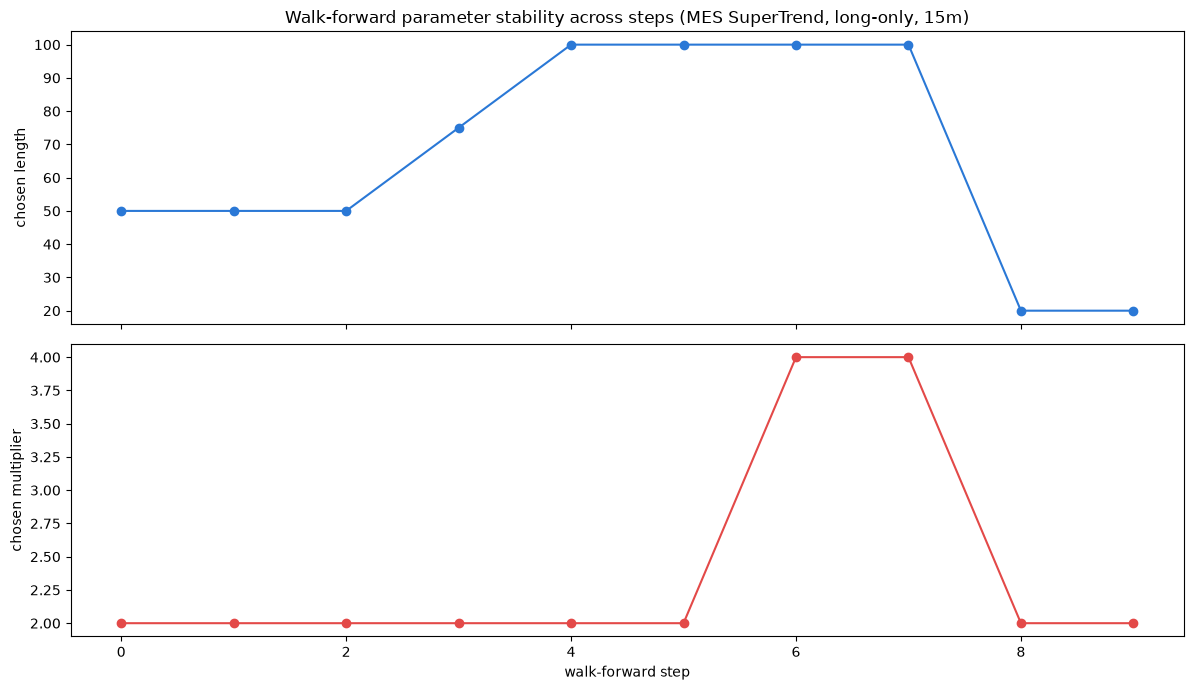

length: unique values chosen = [np.int64(20), np.int64(50), np.int64(75), np.int64(100)]
multiplier: unique values chosen = [np.float64(2.0), np.float64(4.0)]


In [9]:
fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True)
axes[0].plot(wf_results["step"], wf_results["chosen_length"], marker="o", color="#2a78d6")
axes[0].set_ylabel("chosen length")
axes[0].set_title("Walk-forward parameter stability across steps (MES SuperTrend, long-only, 15m)")
axes[1].plot(wf_results["step"], wf_results["chosen_multiplier"], marker="o", color="#e34948")
axes[1].set_ylabel("chosen multiplier")
axes[1].set_xlabel("walk-forward step")
fig.tight_layout()
plt.show()

print(f"length: unique values chosen = {sorted(wf_results['chosen_length'].unique())}")
print(f"multiplier: unique values chosen = {sorted(wf_results['chosen_multiplier'].unique())}")


### The real track record: concatenated out-of-sample trades


In [10]:
wf_trade_sharpe, wf_trade_sharpe_lb, wf_n = trade_sharpe_lb(wf_oos_trades)
wf_wins = sum(1 for t in wf_oos_trades if t.pnl > 0)
wf_win_rate = (wf_wins / wf_n * 100) if wf_n else float("nan")
wf_total_pnl_percent = sum(t.pnl for t in wf_oos_trades) * 100

print(f"Concatenated OOS trades across all {len(wf_steps)} steps: {wf_n}")
print(f"OOS win rate: {wf_win_rate:.2f}%")
print(f"OOS trade_sharpe: {wf_trade_sharpe:.4f}")
print(f"OOS trade_sharpe_lb: {wf_trade_sharpe_lb:.4f}")
print(f"OOS sum of trade pnl (frictionless, %): {wf_total_pnl_percent:.2f}%")


Concatenated OOS trades across all 10 steps: 2275
OOS win rate: 37.32%
OOS trade_sharpe: 0.0228
OOS trade_sharpe_lb: -0.0117
OOS sum of trade pnl (frictionless, %): 28.40%


## Walk-forward conclusion

**Negative -- the single-split holdout's promise does not survive, and this
one is clearer-cut than MNQ Keltner's near-zero result.**

| metric | value |
|---|---|
| OOS trades | 2,275 |
| OOS win rate | 37.3% |
| OOS `trade_sharpe` (point estimate) | +0.023 |
| OOS `trade_sharpe_lb` | **-0.0117** |
| OOS sum of trade pnl (frictionless) | +28.4% |

Only 4 of 10 steps had a positive OOS net return (0, 5, 6, 8) -- the other 6
were flat-to-negative, including two clearly bad windows (step 2: -10.8%,
`dollar_profit_factor` 0.84; step 4: -8.3%, 0.81).

**Parameter selection also wandered more than any other walk-forward in this
pipeline**: `length` moved through 20, 50, 75, and 100 across the 10 steps
with no dominant value, unlike Donchian's or Keltner's walk-forwards, which
each had one length chosen in 8-9 of 10 steps. Per this pipeline's own
walk-forward criterion (`OPTIMIZATION_RESEARCH_PLAN.md` §5.2: "do the chosen
lengths wander wildly? -- if yes, the edge is the re-fitting, i.e. probably
nothing"), this instability is itself evidence against a real, stable edge --
not just the negative lower bound on its own.

**Bottom line**: the single 75/25 holdout's `trade_sharpe_lb=+0.0134` was, in
hindsight, a fit to that particular training window rather than a stable
property of MES SuperTrend long-only. This strategy/symbol pair does not
clear the bar this pipeline has set for a validated edge.
